In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
df1 = pd.read_csv("cleaned_data1.csv", low_memory = False)

In [3]:
df1

,Study,Species,Organism Group,Country,State,Gender,Age Group,Speciality,Source,In / Out Patient,...,Sulbactam,Sulbactam_I,Teicoplanin,Teicoplanin_I,Tetracycline,Tetracycline_I,Trimethoprim sulfa,Trimethoprim sulfa_I,Ceftolozane tazobactam,Ceftolozane tazobactam_I
0,TEST,Pseudomonas aeruginosa,Non-Enterobacteriaceae,France,NaN,Male,85 and Over,Emergency Room,GU: Urine,None Given,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TEST,Pseudomonas aeruginosa,Non-Enterobacteriaceae,France,NaN,Female,13 to 18 Years,Emergency Room,HEENT: Ears,None Given,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TEST,Pseudomonas aeruginosa,Non-Enterobacteriaceae,France,NaN,Female,65 to 84 Years,Nursing Home / Rehab,GU: Urine,None Given,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TEST,Pseudomonas aeruginosa,Non-Enterobacteriaceae,France,NaN,Male,19 to 64 Years,Medicine General,INT: Skin,None Given,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TEST,Serratia marcescens,Enterobacteriaceae,France,NaN,Male,19 to 64 Years,Medicine General,CVS: Blood,None Given,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
633815,TEST,Escherichia coli,Enterobacteriaceae,France,NaN,Male,65 to 84 Years,Emergency Room,GU: Urine,None Given,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
633816,TEST,Escherichia coli,Enterobacteriaceae,France,NaN,Female,0 to 2 Years,Emergency Room,GU: Urine,None Given,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
633817,TEST,Escherichia coli,Enterobacteriaceae,France,NaN,Female,85 and Over,Emergency Room,GU: Urine,None Given,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
633818,TEST,Pseudomonas aeruginosa,Non-Enterobacteriaceae,France,NaN,Female,19 to 64 Years,Surgery General,Bodily Fluids: Peritoneal,None Given,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df1.columns

Index(['Study', 'Species', 'Organism Group', 'Country', 'State', 'Gender',
       'Age Group', 'Speciality', 'Source', 'In / Out Patient', 'Year',
       'Phenotype', 'Amikacin', 'Amikacin_I', 'Amoxycillin clavulanate',
       'Amoxycillin clavulanate_I', 'Ampicillin', 'Ampicillin_I',
       'Azithromycin', 'Azithromycin_I', 'Cefepime', 'Cefepime_I', 'Cefoxitin',
       'Cefoxitin_I', 'Ceftazidime', 'Ceftazidime_I', 'Ceftriaxone',
       'Ceftriaxone_I', 'Clarithromycin', 'Clarithromycin_I', 'Clindamycin',
       'Clindamycin_I', 'Erythromycin', 'Erythromycin_I', 'Imipenem',
       'Imipenem_I', 'Levofloxacin', 'Levofloxacin_I', 'Linezolid',
       'Linezolid_I', 'Meropenem', 'Meropenem_I', 'Metronidazole',
       'Metronidazole_I', 'Minocycline', 'Minocycline_I', 'Penicillin',
       'Penicillin_I', 'Piperacillin tazobactam', 'Piperacillin tazobactam_I',
       'Tigecycline', 'Tigecycline_I', 'Vancomycin', 'Vancomycin_I',
       'Ampicillin sulbactam', 'Ampicillin sulbactam_I', 'Aztre

In [7]:
df = df1[df1.columns.drop(['Study', 'Species', 'Organism Group', 'Country', 'State', 'Gender',
       'Age Group', 'Speciality', 'Source', 'In / Out Patient'])]

In [8]:
interpretationList = []
MICList = []
for i in df.columns:
    if(i.endswith('I')):
        interpretationList.append(i)
    else:
        MICList.append(i)

interpretationList.insert(0, 'Year')

In [7]:
dfI = df[interpretationList]

In [8]:
antimicrobial_cols = dfI.columns.drop('Year')

In [9]:
summaryI = dfI.melt(id_vars= 'Year', value_vars= antimicrobial_cols, var_name= 'Antimicrobial', value_name= 'Result')

In [10]:
summaryI = summaryI.groupby(['Antimicrobial','Year', 'Result']).size()

In [11]:
summaryI2 = summaryI.unstack(fill_value= 0)

In [12]:
summaryI2['Total'] = summaryI2.Intermediate + summaryI2.Resistant + summaryI2.Susceptible

In [13]:
summaryI2['resistantFraction'] = summaryI2.Resistant / summaryI2.Total * 100

In [14]:
s = set()
for i in summaryI2.index:
    s.add(i[0])

In [15]:
s2 = set()
for i in s:
    if(len(summaryI2.loc[i]) < 3):
        summaryI2.drop(index = i, inplace= True)
        s2.add(i)

In [16]:
s = s.difference(s2)

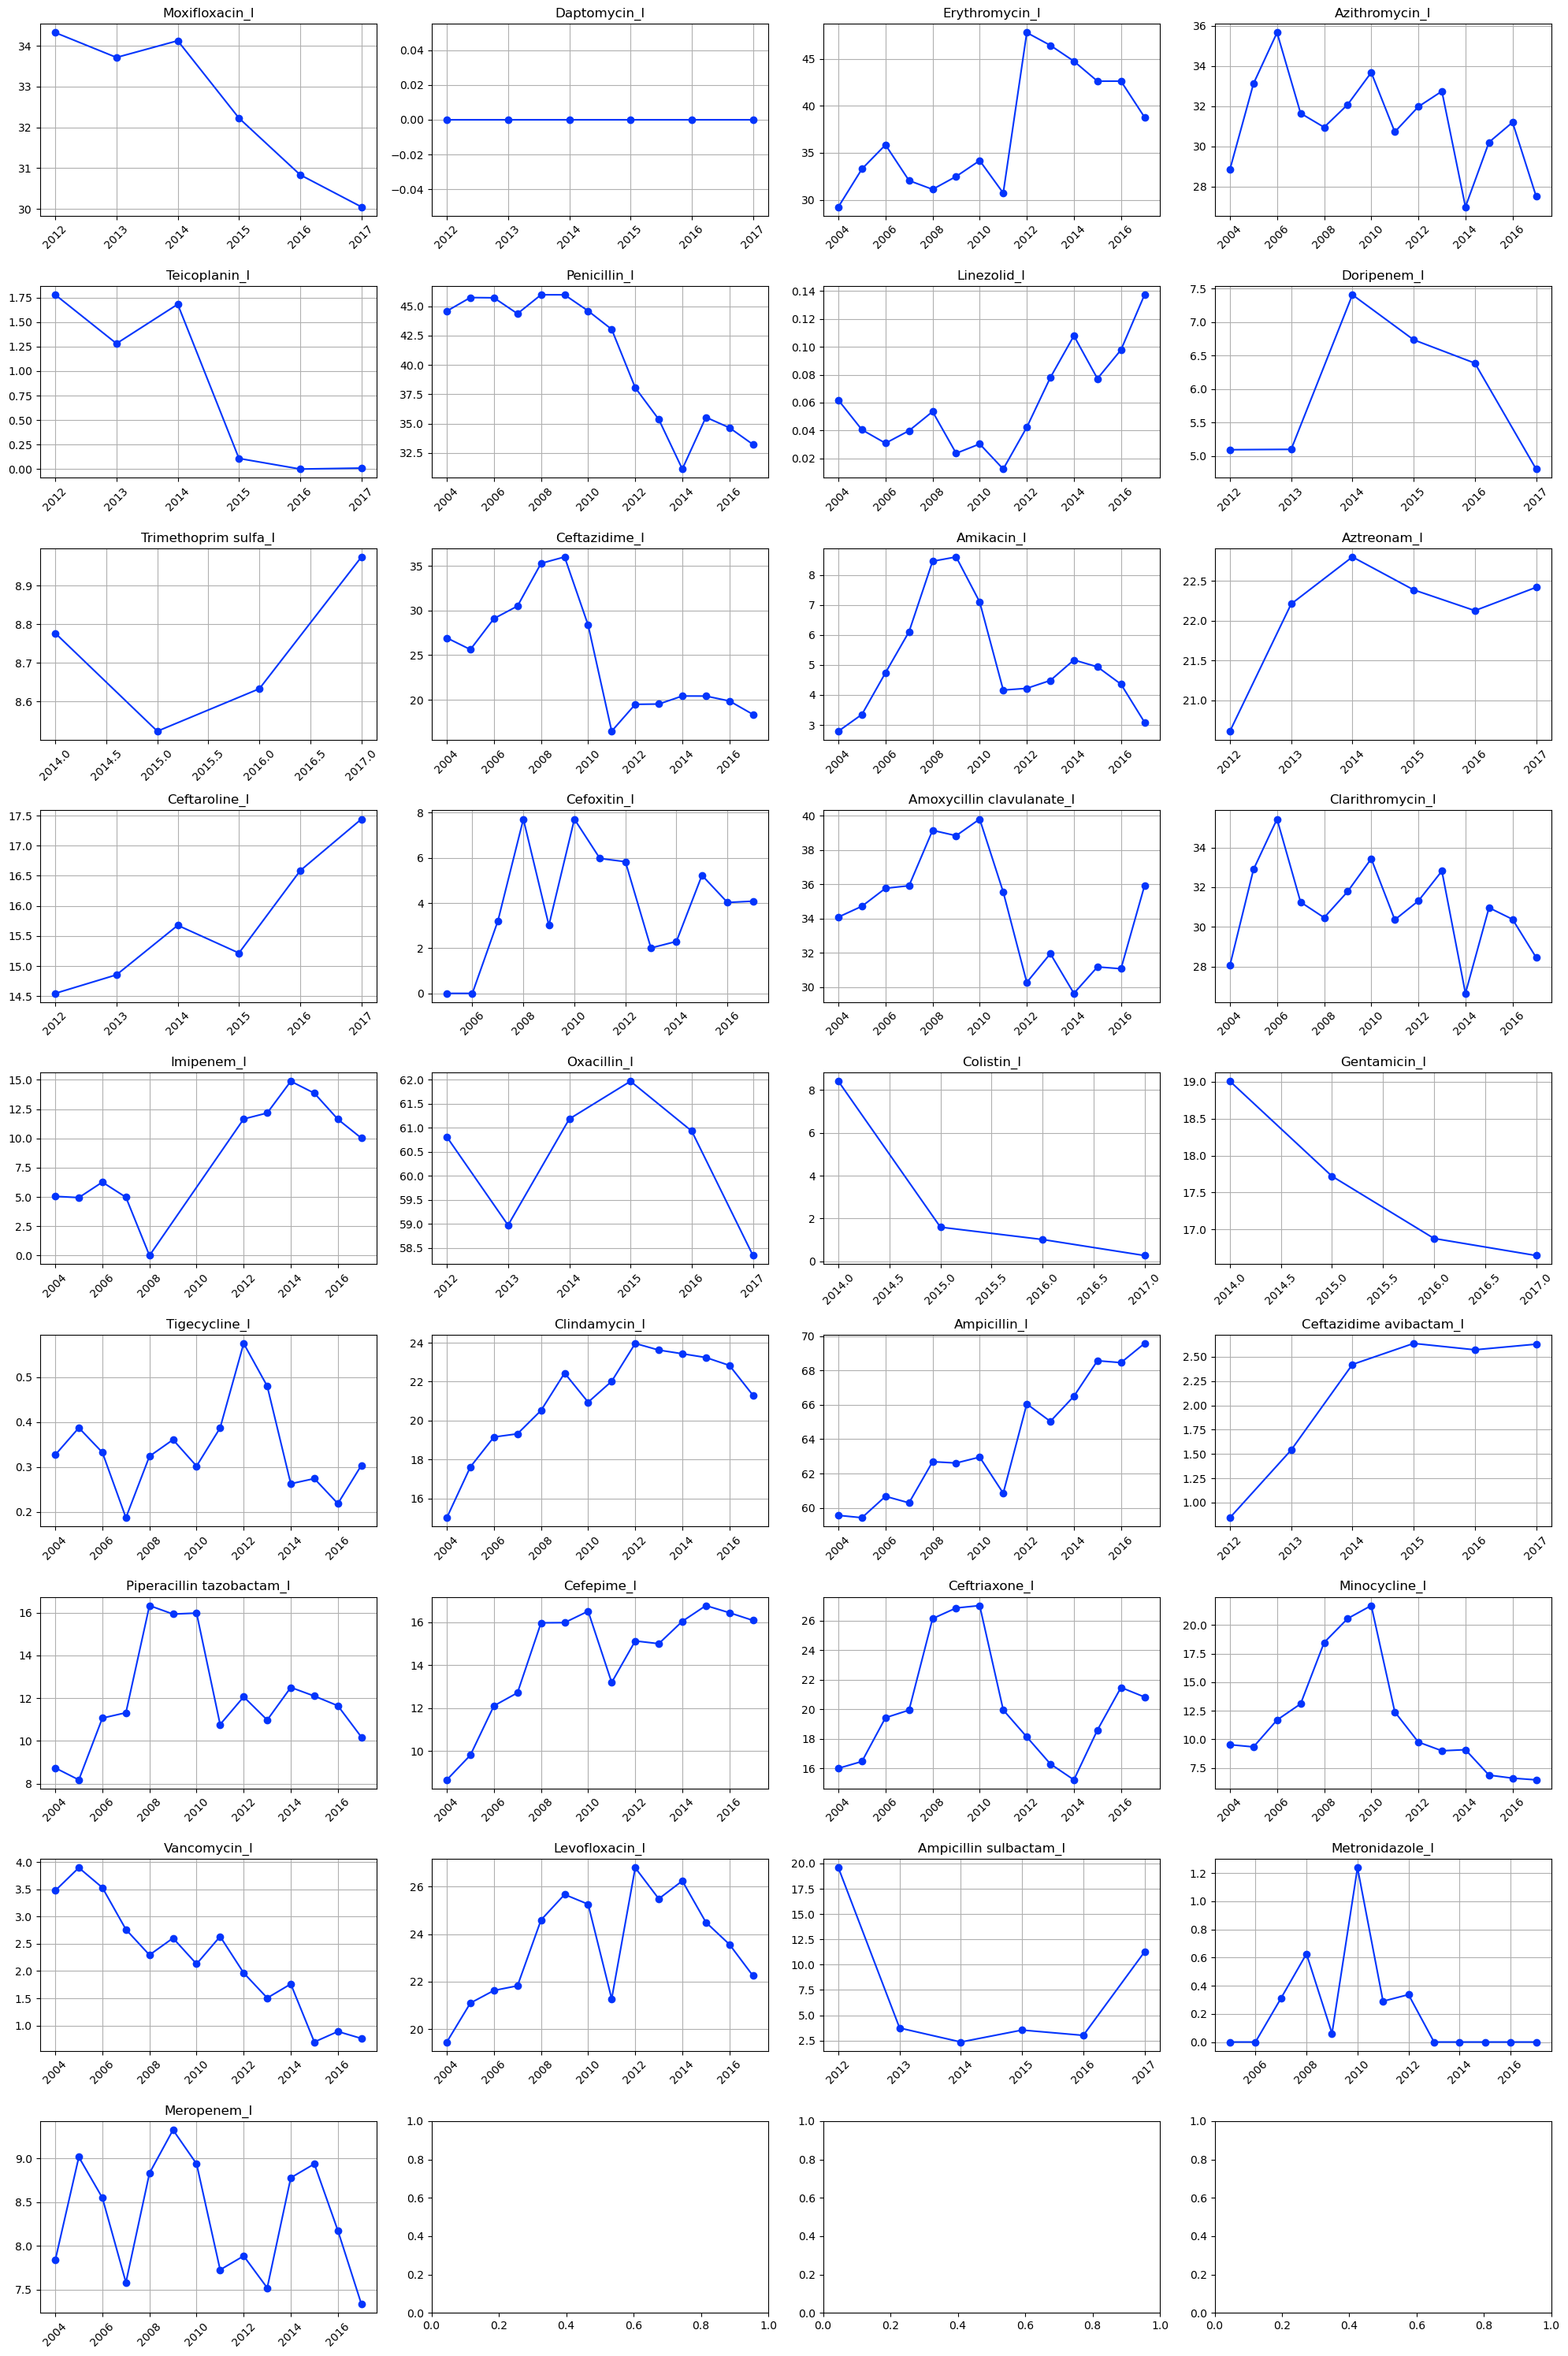

In [17]:
fig, axes = plt.subplots(nrows= 9, ncols= 4, figsize = (20, 10 * 3))
axes = axes.flatten()

for i, antimicrobial in enumerate(s):
    antimicrobial_data = summaryI2.loc[antimicrobial]

    axes[i].plot(antimicrobial_data.index, antimicrobial_data['resistantFraction'], marker='o',
         linestyle='-',
         label = 'Resistance',
         color = "#0335fc")
    
    axes[i].set_title(antimicrobial)
    axes[i].grid(True)
    axes[i].tick_params(axis = 'x', rotation = 45)
plt.tight_layout()
plt.show()

Upto this point we can see that some antibiotics have lowered effects while other are performing better. Next we try to find some relation between the antibiotics that shows increased resistance and lowered resistance.

In [18]:
for antimicrobial in s:
    df_antimicrobial = summaryI2.loc[antimicrobial]
    df_antimicrobial.index -= df_antimicrobial.index[0]
    x = sm.add_constant(df_antimicrobial.index)
    model = sm.OLS(df_antimicrobial.resistantFraction, x).fit()
    print("\n\n",antimicrobial)
    print(model.summary())



 Moxifloxacin_I
                            OLS Regression Results                            
Dep. Variable:      resistantFraction   R-squared:                       0.893
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     33.50
Date:                Sun, 08 Mar 2026   Prob (F-statistic):            0.00443
Time:                        02:57:01   Log-Likelihood:                -4.7889
No. Observations:                   6   AIC:                             13.58
Df Residuals:                       4   BIC:                             13.16
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         34.8228      0.476  

/usr/lib/python3/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/lib/python3/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/lib/python3/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/lib/python3/dist-packages/statsmodels/regression/linear_model.py:1871: RuntimeWarning: invalid value encountered in scalar divide
  return self.mse_model/self.mse_resid
/usr/lib/python3/dist-packages/statsmodels/regression/linear_model.py:957: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs

                            OLS Regression Results                            
Dep. Variable:      resistantFraction   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                 -0.113
Method:                 Least Squares   F-statistic:                    0.4925
Date:                Sun, 08 Mar 2026   Prob (F-statistic):              0.522
Time:                        02:57:01   Log-Likelihood:                -19.183
No. Observations:                   6   AIC:                             42.37
Df Residuals:                       4   BIC:                             41.95
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.2872      5.247      1.961      0.1

Clustering

In [9]:
df1.columns

Index(['Study', 'Species', 'Organism Group', 'Country', 'State', 'Gender',
       'Age Group', 'Speciality', 'Source', 'In / Out Patient', 'Year',
       'Phenotype', 'Amikacin', 'Amikacin_I', 'Amoxycillin clavulanate',
       'Amoxycillin clavulanate_I', 'Ampicillin', 'Ampicillin_I',
       'Azithromycin', 'Azithromycin_I', 'Cefepime', 'Cefepime_I', 'Cefoxitin',
       'Cefoxitin_I', 'Ceftazidime', 'Ceftazidime_I', 'Ceftriaxone',
       'Ceftriaxone_I', 'Clarithromycin', 'Clarithromycin_I', 'Clindamycin',
       'Clindamycin_I', 'Erythromycin', 'Erythromycin_I', 'Imipenem',
       'Imipenem_I', 'Levofloxacin', 'Levofloxacin_I', 'Linezolid',
       'Linezolid_I', 'Meropenem', 'Meropenem_I', 'Metronidazole',
       'Metronidazole_I', 'Minocycline', 'Minocycline_I', 'Penicillin',
       'Penicillin_I', 'Piperacillin tazobactam', 'Piperacillin tazobactam_I',
       'Tigecycline', 'Tigecycline_I', 'Vancomycin', 'Vancomycin_I',
       'Ampicillin sulbactam', 'Ampicillin sulbactam_I', 'Aztre

In [10]:
df1['Organism Group'].value_counts()

Organism Group
Enterobacteriaceae                  260196
Staphylococcus spp                  129178
Non-Enterobacteriaceae               96435
Enterococcus spp                     37081
Streptococcus pneumoniae             36765
Streptococcus spp (no S. pneumo)     33183
Haemophilus spp                      26696
Gram Negative Anaerobes               7076
Gram Positive Anaerobes               6340
Moraxellaceae                          797
Neisseria gonorrhoeae                   73
Name: count, dtype: int64

In [11]:
df_microbes = df1[['Organism Group'] + interpretationList]

In [12]:
df_microbes_long = df_microbes.melt(id_vars= ['Year', 'Organism Group'], var_name='Antimicrobial', value_name = 'Status')

In [13]:
df_microbes_long

,Year,Organism Group,Antimicrobial,Status
0,2013,Non-Enterobacteriaceae,Amikacin_I,Susceptible
1,2013,Non-Enterobacteriaceae,Amikacin_I,Susceptible
2,2013,Non-Enterobacteriaceae,Amikacin_I,Susceptible
3,2013,Non-Enterobacteriaceae,Amikacin_I,Susceptible
4,2013,Enterobacteriaceae,Amikacin_I,Susceptible
...,...,...,...,...
27888075,2013,Enterobacteriaceae,Ceftolozane tazobactam_I,NaN
27888076,2013,Enterobacteriaceae,Ceftolozane tazobactam_I,NaN
27888077,2013,Enterobacteriaceae,Ceftolozane tazobactam_I,NaN
27888078,2013,Non-Enterobacteriaceae,Ceftolozane tazobactam_I,NaN


In [14]:
mapping = {"Resistant":1, "Intermediate":0.5, "Susceptible":0}
df_microbes_long["Resistance_score"] = df_microbes_long["Status"].map(mapping)

In [15]:
matrix = df_microbes_long.pivot_table(index="Organism Group",columns="Antimicrobial", 
                                      values="Resistance_score", aggfunc="mean")

In [17]:
matrix.fillna(value=0, inplace=True)

Antimicrobial,Amikacin_I,Amoxycillin clavulanate_I,Ampicillin sulbactam_I,Ampicillin_I,Azithromycin_I,Aztreonam_I,Cefepime_I,Cefixime_I,Cefoxitin_I,Ceftaroline_I,...,Moxifloxacin_I,Oxacillin_I,Penicillin_I,Piperacillin tazobactam_I,Quinupristin dalfopristin_I,Teicoplanin_I,Tetracycline_I,Tigecycline_I,Trimethoprim sulfa_I,Vancomycin_I
Organism Group,,,,,,,,,,,,,,,,,,,,,
Enterobacteriaceae,0.021480,0.475078,0.000000,0.823988,0.136364,0.234539,0.164293,0.0,0.000000,0.337661,...,0.000000,0.000000,0.000000,0.122944,0.000000,0.000000,0.000000,0.021507,0.000000,0.000000
Enterococcus spp,0.000000,0.000000,0.000000,0.287641,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.272572,0.000000,0.621964,0.109030,0.000000,0.005771,0.000000,0.120938
Gram Negative Anaerobes,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.086443,0.000000,...,0.000000,0.000000,0.000000,0.018725,0.000000,0.000000,0.000000,0.022188,0.000000,0.000000
Gram Positive Anaerobes,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.201530,0.008517,0.000000,0.000000,0.000000,0.000710,0.000000,0.000000
Haemophilus spp,0.000000,0.005282,0.057029,0.207597,0.134868,0.000855,0.002573,0.0,0.000000,0.003050,...,0.000000,0.000000,0.000000,0.001798,0.000000,0.000000,0.000000,0.000094,0.000000,0.000000
Neisseria gonorrhoeae,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.589041,0.000000,0.000000,0.000000
Non-Enterobacteriaceae,0.167939,0.000000,0.000000,0.000000,0.000000,0.295814,0.278300,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.304068,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Staphylococcus spp,0.000000,0.000000,0.000000,0.000000,0.347011,0.000000,0.000000,0.0,0.000000,0.033762,...,0.408005,0.603984,0.882915,0.000000,0.000000,0.001669,0.000000,0.003031,0.087176,0.000054
Streptococcus pneumoniae,0.000000,0.062085,0.000000,0.000000,0.319389,0.000000,0.000000,0.0,0.000000,0.001529,...,0.011870,0.000000,0.267211,0.000000,0.000000,0.000000,0.000000,0.002761,0.000000,0.000027


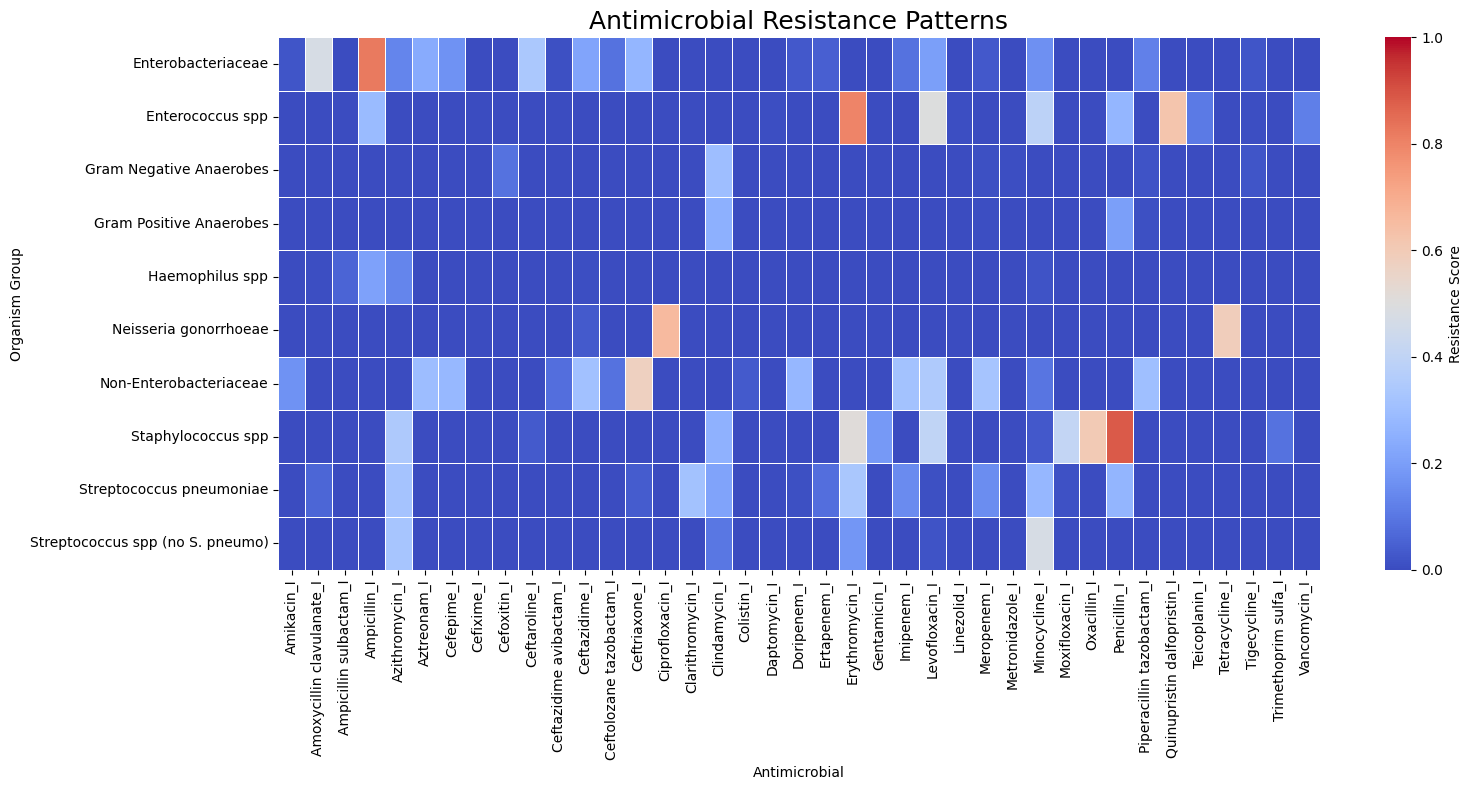

In [18]:
plt.figure(figsize=(16,8))

sns.heatmap(
    matrix,
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    linewidths=0.4,
    cbar_kws={'label': 'Resistance Score'}
)

plt.title("Antimicrobial Resistance Patterns", fontsize=18)

plt.tight_layout()

plt.show()

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [31]:
scaler = StandardScaler()
matrix_scaled = scaler.fit_transform(matrix)

In [32]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(matrix_scaled)

matrix["Cluster"] = clusters

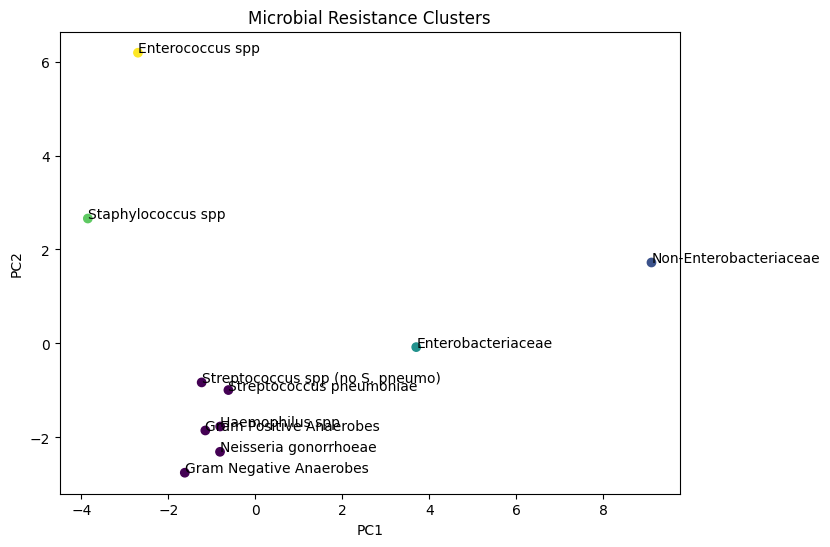

In [33]:
pca = PCA(n_components=2)
components = pca.fit_transform(matrix_scaled)

plt.figure(figsize=(8,6))
plt.scatter(components[:,0], components[:,1], c=clusters)

for i, label in enumerate(matrix.index):
    plt.text(components[i,0], components[i,1], label)

plt.title("Microbial Resistance Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()